In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
print("Libraries ready")

Libraries ready


In [113]:
df = pd.read_csv('zomato.csv')
print("Data loaded! Shape:", df.shape)

Data loaded! Shape: (56252, 13)


In [114]:
print(df.columns)

Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')


In [115]:
print("🔧 Starting Data Cleaning...")

# Safe way to drop columns (ignores if column doesn't exist)
df.drop(['url', 'address', 'phone', 'dish_liked', 'menu_item', 'listed_in(type)'],
        axis=1,
        inplace=True,
        errors='ignore')

# Rename columns safely
df.rename(columns={
    'approx_cost(for two people)': 'cost_for_two',
    'listed_in(city)': 'area'
}, inplace=True)

# Clean Rating column
df['rate'] = df['rate'].astype(str).str.replace('/5', '').str.strip()
df['rate'] = df['rate'].replace(['NEW', '-', 'nan', 'None'], np.nan)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Clean Cost column
df['cost_for_two'] = df['cost_for_two'].astype(str).str.replace(',', '', regex=False)
df['cost_for_two'] = pd.to_numeric(df['cost_for_two'], errors='coerce')

# Handle missing values
df.dropna(subset=['rate', 'cost_for_two'], inplace=True)
df['cuisines'].fillna('Unknown', inplace=True)
df['rest_type'].fillna('Others', inplace=True)

print("✅ Cleaning Completed!")
print("Current columns:", df.columns.tolist())
print("Final shape:", df.shape)

🔧 Starting Data Cleaning...
✅ Cleaning Completed!
Current columns: ['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'cost_for_two']
Final shape: (41418, 9)


In [116]:
print("✅ Data is Ready for Analysis!")
print("Shape after cleaning:", df.shape)
print("\nColumns available:")
print(df.columns.tolist())

df.head()

✅ Data is Ready for Analysis!
Shape after cleaning: (41418, 9)

Columns available:
['name', 'online_order', 'book_table', 'rate', 'votes', 'location', 'rest_type', 'cuisines', 'cost_for_two']


,name,online_order,book_table,rate,votes,location,rest_type,cuisines,cost_for_two
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800.0
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800.0
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800.0
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300.0
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600.0


In [117]:
# Basic Statistics
print("📊 KEY STATISTICS")
print(f"Total Restaurants Analyzed : {len(df):,}")
print(f"Average Rating            : {df['rate'].mean():.2f}/5")
print(f"Highest Rating            : {df['rate'].max()}")
print(f"Average Cost for Two      : ₹{df['cost_for_two'].mean():.0f}")
print(f"Most Expensive            : ₹{df['cost_for_two'].max():.0f}")

📊 KEY STATISTICS
Total Restaurants Analyzed : 41,418
Average Rating            : 3.70/5
Highest Rating            : 4.9
Average Cost for Two      : ₹603
Most Expensive            : ₹6000


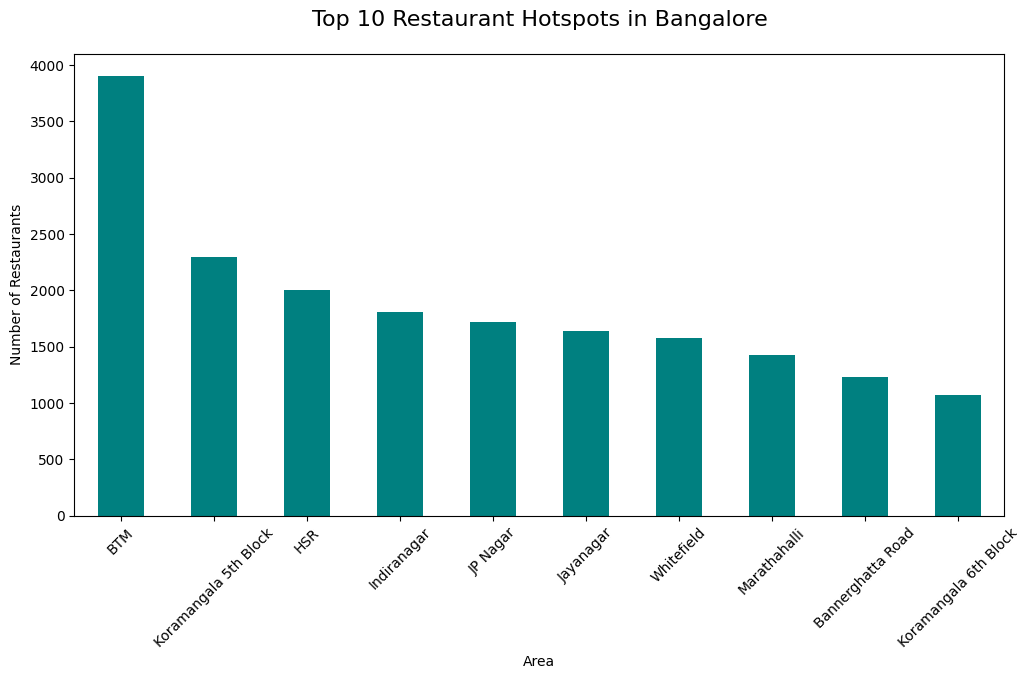

In [118]:
plt.figure(figsize=(12, 6))
df['location'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('Top 10 Restaurant Hotspots in Bangalore', fontsize=16, pad=20)
plt.xlabel('Area')
plt.ylabel('Number of Restaurants')
plt.xticks(rotation=45)
plt.show()

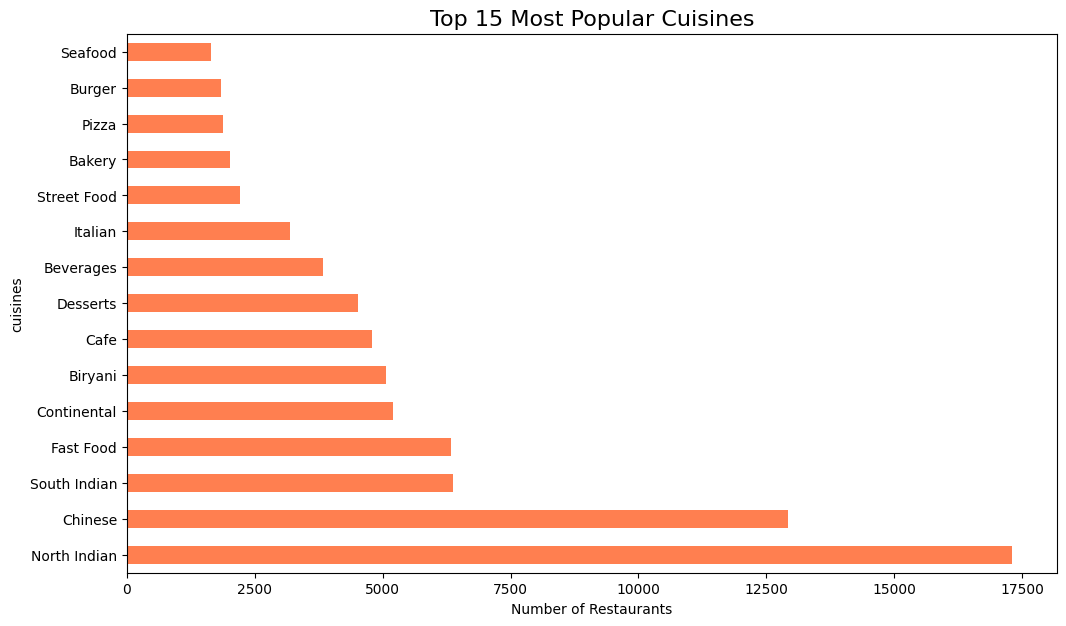

In [119]:
cuisines_exploded = df['cuisines'].str.split(', ').explode()

plt.figure(figsize=(12, 7))
cuisines_exploded.value_counts().head(15).plot(kind='barh', color='coral')
plt.title('Top 15 Most Popular Cuisines', fontsize=16)
plt.xlabel('Number of Restaurants')
plt.show()

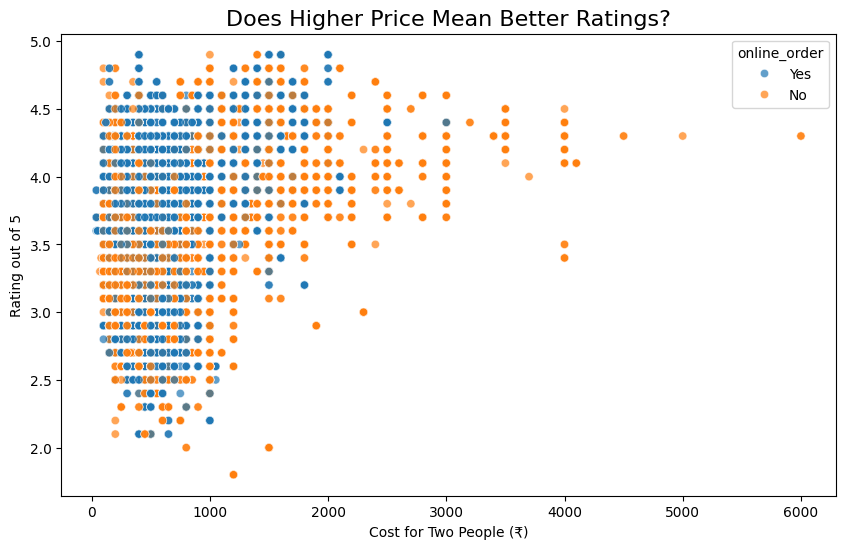

In [120]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='cost_for_two', y='rate', alpha=0.7, hue='online_order')
plt.title('Does Higher Price Mean Better Ratings?', fontsize=16)
plt.xlabel('Cost for Two People (₹)')
plt.ylabel('Rating out of 5')
plt.show()

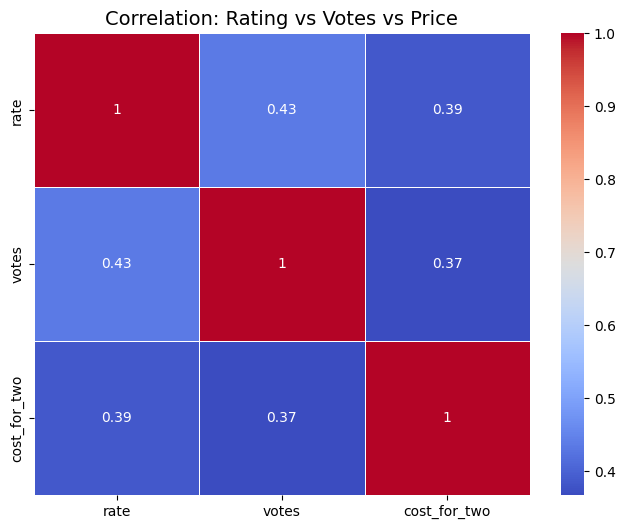

In [121]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['rate', 'votes', 'cost_for_two']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation: Rating vs Votes vs Price', fontsize=14)
plt.show()

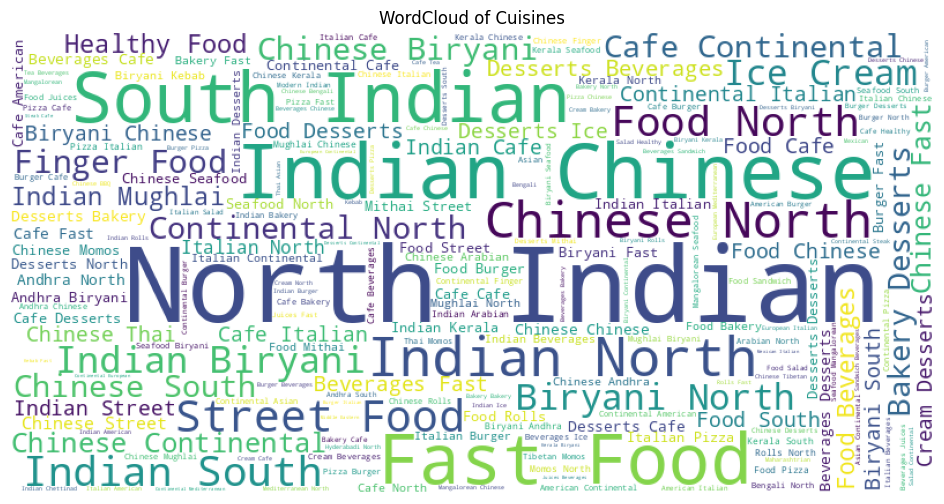

In [125]:
text = ' '.join(df['cuisines'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('WordCloud of Cuisines')
plt.show()

In [123]:
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
location,0
rest_type,0
cuisines,0
cost_for_two,0
